In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll
import torch
import torch.nn as nn

In [64]:
def sample_batch(batch_size, device='cpu'):
    data, _ = make_swiss_roll(batch_size)
    data = data[:, [2, 0]] / 10 # Use only two dimensions
    data = data * np.array([1, -1])
    data = torch.from_numpy(data).float().to(device)
    return data

In [39]:
n_samples = 5000
data, _ = make_swiss_roll(n_samples)

In [40]:
data.shape

(5000, 3)

In [41]:
data = data[:, [2, 0]] / 10 # Use only two dimensions for visualization
data = data * np.array([1, -1])
data = torch.from_numpy(data).float()

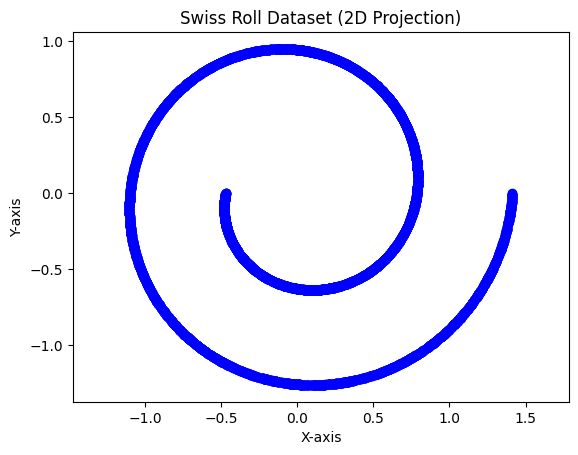

In [42]:
plt.scatter(data[:, 0], data[:, 1], c='blue')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Swiss Roll Dataset (2D Projection)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

In [43]:
def forward_process(data, T, betas):
    for t in range(T):
        beta_t = betas[t]
        mu = data * torch.sqrt(1 - beta_t)
        std = torch.sqrt(beta_t)
        # Sample from q(x_t | x_{t-1})
        data = mu + torch.randn_like(data) * std
    return data

In [44]:
T = 40
betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
xT = forward_process(data, T, betas)

In [45]:
print(xT.mean(0))
print(xT.std(0))

tensor([ 0.0352, -0.0396])
tensor([0.9926, 1.0125])


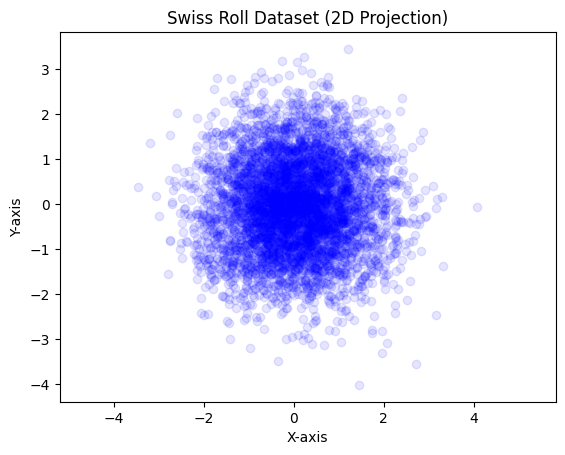

In [46]:
plt.scatter(xT[:, 0], xT[:, 1], c='blue', alpha=0.1)
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Swiss Roll Dataset (2D Projection)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

In [52]:
class MLP(nn.Module):
    def __init__(self, N=40, data_dim=2, hidden_dim=64):
        super(MLP, self).__init__()
        self.N = N
        self.data_dim = data_dim
        self.hidden_dim = hidden_dim
        self.network_head = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU())
        self.network_tail = nn.ModuleList([nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim * 2)) for _ in range(N)])
        
    def forward(self, x, t):
        h = self.network_head(x)
        out = self.network_tail[t](h)
        mu, log_var = out.chunk(2, dim=-1)
        var = torch.exp(log_var)
        std = torch.sqrt(var)
        return mu, std


In [53]:
model = MLP()
xt = torch.randn((64, 2))
t = 5
mu, std = model(xt, t)
print(mu.shape, std.shape)

torch.Size([64, 2]) torch.Size([64, 2])


In [54]:
class DiffusionModel:
    def __init__(self, T, model: nn.Module, dim=2):
        super(DiffusionModel, self).__init__()
        self.T = T
        self.betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.model = model  # This should be a neural network model
        self.dim = dim

    def forward_process(self, x0, t):
        assert t > 0, "t must be greater than 0"
        assert t <= self.T , "t must be less than or equal to T"

        t = t - 1  # Adjust for 0-based indexing
        mu = torch.sqrt(self.alpha_bars[t-1]) * x0
        std = torch.sqrt(1 - self.alpha_bars[t])
        epsilon = torch.randn_like(x0)  # Sample noise
        xt = mu + std * epsilon
        return xt
    
    def reverse_process(self, xt, t):
        assert t > 0 , "t must be greater than 0"
        assert t <= self.T , "t must be less than or equal to T"
        t = t - 1  # Adjust for 0-based indexing
        mu, std = self.model(xt, t)  # Predict the mean and std using the model
        return mu + std * torch.randn_like(xt)  # Sample from p(x_{t-1} | x_t)
        
    def sample(self, batch_size):
        noise = torch.randn((batch_size, self.dim))
        x = noise
        samples = [x.detach().cpu().numpy()]
        for t in range(self.T, 0, -1):
            if not (t == 1):
                x = self.reverse_process(x, t)
            samples.append(x.detach().cpu().numpy())
        return samples[::-1]  # Return in chronological order

In [60]:
x0 = sample_batch(3_000)
mlp_model = MLP()#torch.load('model_paper1')
model = DiffusionModel(40, mlp_model)
xT = model.forward_process(x0, 20)
#xt = model.forward_process(x0, t=40)

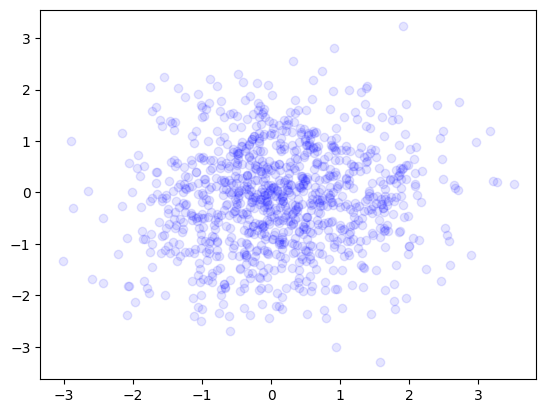

In [61]:
samples = model.sample(batch_size=1_000)
plt.scatter(samples[0][:, 0], samples[0][:, 1], c='blue', alpha=0.1)


In [62]:
print(xT.mean(0))
print(xT.std(0))

tensor([ 0.0072, -0.2008])
tensor([0.6992, 0.6575])


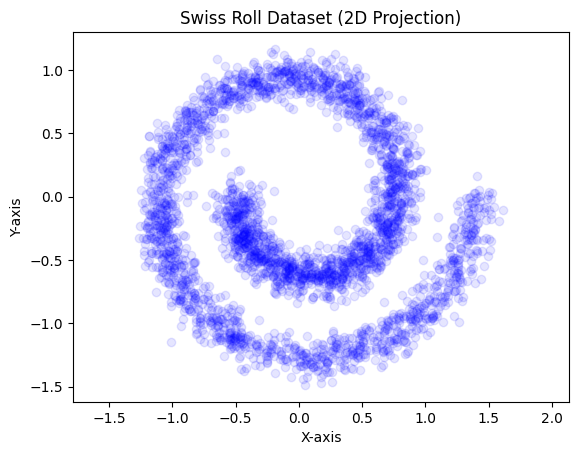

In [63]:
plt.scatter(xT[:, 0], xT[:, 1], c='blue', alpha=0.1)
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Swiss Roll Dataset (2D Projection)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

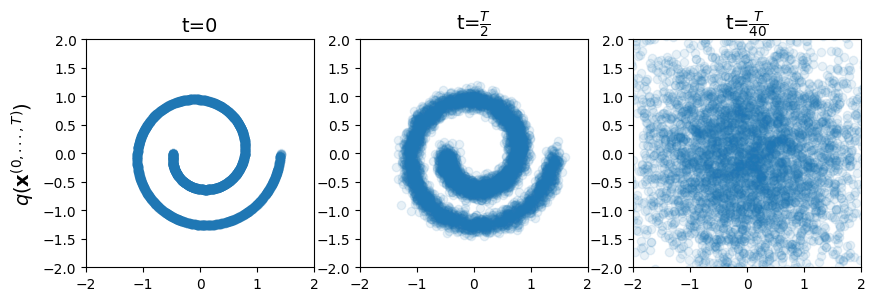

<Figure size 640x480 with 0 Axes>

In [16]:
fontsize = 14
fig = plt.figure(figsize=(10, 3))
data = [x0, model.forward_process(x0, t=20), model.forward_process(x0, t=40)]
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.scatter(data[i][:, 0].cpu().numpy(), data[i][:, 1].cpu().numpy(), alpha=0.1)
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.gca().set_aspect('equal', adjustable='box')
    if i == 0:
        plt.ylabel(r'$q(\mathbf{x}^{(0,...,T)})$', fontsize=fontsize)
        plt.title('t=0', fontsize=fontsize)
    if i == 1:
        plt.title(r't=$\frac{T}{2}$', fontsize=fontsize)
    if i == 2:
        plt.title(r't=$\frac{T}{40}$', fontsize=fontsize)
plt.show()
plt.savefig('forward_process.png', bbox_inches='tight')
